In [34]:
import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from sotodlib import core
from sotodlib.tod_ops.flags import get_det_bias_flags

from latcom.utils.cut_utils import get_cut_sources, get_det_cal_cuts, get_yield_stages
import latcom.utils.yield_utils as yd
from latcom.utils.optical_loading import (
    aso_tubes,
    lf_tubes,
    ot_from_ufm,
    pwv_interp,
    so_nominal_tubes,
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# ASO Yields

In [128]:
ctx = core.Context("../../ctxs/smurf_det_preproc.yaml")
ufm = "mv13"
band = "150"
ot = ot_from_ufm(ufm)

start = dt.datetime(2026, 6, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2026, 6, 30, tzinfo=dt.timezone.utc)


obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)


pwv = pwv_interp()

obs_ctx_list = []
for i, obs in enumerate(obs_list):
    cur_ot = str(obs["obs_id"]).split("_")[2][3:]
    obs_id = str(obs["obs_id"])
    if cur_ot in lf_tubes:
        obs_ctx_list.append((obs_id, "../../ctxs/preprocess_lf_260604.yaml"))
    else:
        obs_ctx_list.append((obs_id, "../../ctxs/preprocess_260604.yaml"))

toby_df = yd.aso_toby_df
pton_df = yd.ptown_df

In [129]:
for obs_id, ctx_path in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        ctx = core.Context(ctx_path)
        break
aso_metas = []
for obs_id, ctx_path in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = ctx.get_meta(
                obs_id,
                dets={
                    "dets:stream_id": "ufm_" + str(ufm),
                    "dets:wafer.bandpass": "f" + str(band),
                },
            )
            aso_metas.append(meta)

        except:
            continue

obs_1780451618_lati3_111
obs_1780451618_lati3_111


/global/u2/j/jorlo/dev/sotodlib/sotodlib/core/metadata/loader.py:996: MetadataSpecWarning: metadata spec contains 'unpack' and 'name' entries; ignoring the latter (except to set the 'label', maybe).
  warnings.warn(


obs_1780456042_lati3_111
obs_1780458280_lati3_111
obs_1780461905_lati3_111
obs_1780466513_lati3_111
obs_1780469103_lati3_111
obs_1780472708_lati3_111
obs_1780476307_lati3_111
obs_1780485790_lati3_111
obs_1780487540_lati3_111
obs_1780491165_lati3_111
obs_1780500456_lati3_111
obs_1780506301_lati3_111
obs_1780508757_lati3_111
obs_1780512397_lati3_111
obs_1780515999_lati3_111
obs_1780519593_lati3_111
obs_1780521697_lati3_111
obs_1780523870_lati3_111
obs_1780527481_lati3_111
obs_1780534503_lati3_111
obs_1780547839_lati3_111
obs_1780548942_lati3_111
obs_1780552544_lati3_111
obs_1780556149_lati3_111
obs_1780559751_lati3_111
obs_1780564377_lati3_111
obs_1780566939_lati3_111
obs_1780570543_lati3_111
obs_1780577678_lati3_111
obs_1780581344_lati3_111
obs_1780584944_lati3_111
obs_1780593584_lati3_111
obs_1780618057_lati3_111
obs_1780621042_lati3_111
obs_1780634280_lati3_111
obs_1780638066_lati3_111
obs_1780641661_lati3_111
obs_1780645254_lati3_111
obs_1780649884_lati3_111
obs_1780652450_lati3_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v2/preprocessing/archives//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1780656053_lati3_111', 'dets:stream_id': 'ufm_mv13', 'dets:wafer.bandpass': 'f150'}




obs_1780683454_lati3_111
obs_1780687240_lati3_111
obs_1780692145_lati3_111
obs_1780693988_lati3_111
obs_1780697561_lati3_111
obs_1780701149_lati3_111
obs_1780706798_lati3_111
obs_1780710761_lati3_111
obs_1780714397_lati3_111


...

obs_1782760530_lati3_111


obs_1782763188_lati3_111


obs_1782768759_lati3_111


obs_1782771418_lati3_111


obs_1782774012_lati3_111


In [130]:
obs_ids = []
times = []
naive_yields = []
noise_yields = []
n_cuts = []
cut_names = []
pwvs = []

for i in range(len(aso_metas)):
    meta = aso_metas[i]
    obs_id = meta.obs_info.obs_id

    ndet, stage_name = get_yield_stages(meta=meta, ufm=ufm, band=band)
    naive_yield = ndet[0] / 860

    print(
        "Number of dets after get_bias_flags: ",
        naive_yield * 860,
        " current yield ",
        naive_yield,
    )
    noise_yield = ndet[-1] / 860
    noise_yields.append(noise_yield)

    n_cut, cut_name = -1*np.diff(ndet), stage_name[1:]
    n_cuts.append(n_cut)
    cut_names.append(cut_name)
    obs_ids.append(obs_id.split("_")[1])
    times.append(dt.datetime.fromtimestamp(int(obs_id.split("_")[1])))
    naive_yields.append(naive_yield)

    print(
        "Number of dets with noise estimate: ",
        noise_yield * 860,
        " current yield ",
        noise_yield,
    )
    pwvs.append(pwv(obs_id.split("_")[1]))

Number of dets after get_bias_flags:  610.0  current yield  0.7093023255813954
Number of dets with noise estimate:  533.0  current yield  0.6197674418604651
Number of dets after get_bias_flags:  610.0  current yield  0.7093023255813954
Number of dets with noise estimate:  553.0  current yield  0.6430232558139535
Number of dets after get_bias_flags:  610.0  current yield  0.7093023255813954
Number of dets with noise estimate:  549.0  current yield  0.6383720930232558
Number of dets after get_bias_flags:  610.0  current yield  0.7093023255813954
Number of dets with noise estimate:  562.0  current yield  0.6534883720930232
Number of dets after get_bias_flags:  610.0  current yield  0.7093023255813954
Number of dets with noise estimate:  572.0  current yield  0.6651162790697674
Number of dets after get_bias_flags:  610.0  current yield  0.7093023255813954
Number of dets with noise estimate:  534.0  current yield  0.6209302325581395
Number of dets after get_bias_flags:  610.0  current yield

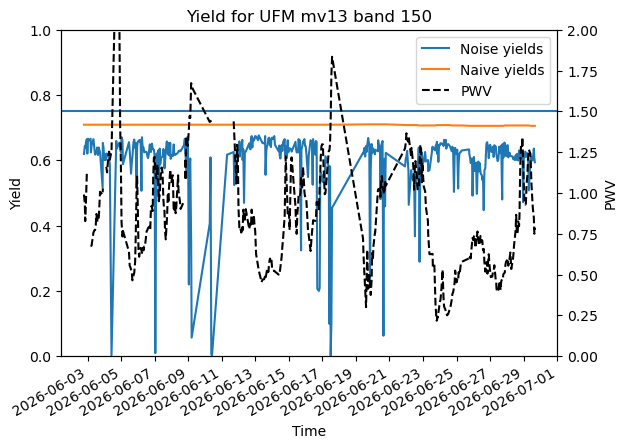

In [131]:
import matplotlib.dates as mdates

fig, ax = plt.subplots()
noise = ax.plot(times, noise_yields, label="Noise yields")
bias = ax.plot(times, naive_yields, label="Naive yields")

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Yield")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

ax.axhline(
    pton_df.loc[pton_df.labels == f"{band}_{ufm}", "yields"].to_numpy(), label="PTon"
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = noise + bias + pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"yield_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"yield_{ufm}_{band}.png", dpi=600)

plt.show()

In [132]:
cuts = cut_names[0]
for i in range(len(cut_names)):
    if i == 0:
        cut_dict = {}
        for name in cuts:
            cut_dict[name] = []
    for j, name in enumerate(cuts):
        cut_dict[name].append(n_cuts[i][j])

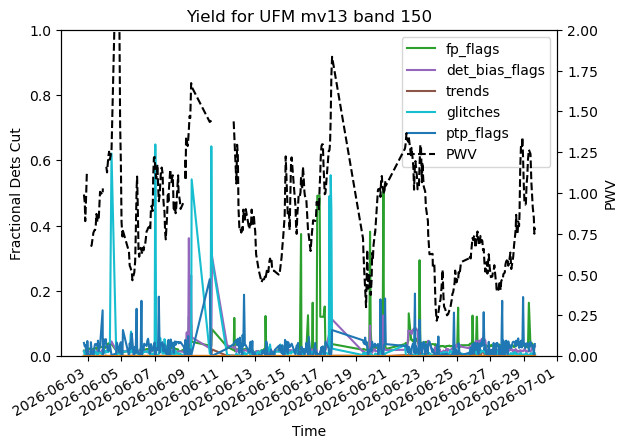

In [133]:
fig, ax = plt.subplots()
lns = []
for cut, n_cut in cut_dict.items():
    cur_ln = ax.plot(times, np.array(n_cut) / 860, label=cut)
    if np.amax(n_cut)>10 and cut !="source_flags":
        lns += cur_ln

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Fractional Dets Cut")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = lns+ pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"cuts_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"cuts_{ufm}_{band}.png", dpi=600)

plt.show()

# SO Nominal Yields

In [134]:
start = dt.datetime(2025, 10, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2025, 10, 30, tzinfo=dt.timezone.utc)


obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)

obs_ids_list = []
for i, obs in enumerate(obs_list):
    obs_ids_list.append(str(obs["obs_id"]))

In [135]:
old_ctx = core.Context("../../ctxs/old_smurf_det_preproc.yaml")
nominal_metas = []
for obs_id in obs_ids_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = old_ctx.get_meta(
                obs_id,
                dets={
                    "dets:stream_id": "ufm_" + str(ufm),
                    "dets:wafer.bandpass": "f" + str(band),
                },
            )
            nominal_metas.append(meta)

        except:
            continue

obs_1759277311_lati3_111
obs_1759279473_lati3_111
obs_1759283082_lati3_111
obs_1759286672_lati3_111
obs_1759291142_lati3_111
obs_1759293432_lati3_111
obs_1759297038_lati3_111
obs_1759300634_lati3_111
obs_1759304242_lati3_111
obs_1759307682_lati3_111
obs_1759309856_lati3_111
obs_1759313447_lati3_111
obs_1759319138_lati3_111
obs_1759321590_lati3_111
obs_1759325208_lati3_111
obs_1759332347_lati3_111
obs_1759337258_lati3_111
obs_1759339810_lati3_111
obs_1759352283_lati3_111
obs_1759354032_lati3_111
obs_1759357619_lati3_111
obs_1759367544_lati3_111
obs_1759369161_lati3_111
obs_1759372753_lati3_111
obs_1759377302_lati3_111
obs_1759379465_lati3_111
obs_1759383059_lati3_111
obs_1759386660_lati3_111
obs_1759390266_lati3_111
obs_1759393846_lati3_111
obs_1759395575_lati3_111
obs_1759399156_lati3_111
obs_1759404891_lati3_111
obs_1759407264_lati3_111
obs_1759410834_lati3_111
obs_1759438886_lati3_111
obs_1759441252_lati3_111
obs_1759444830_lati3_111
obs_1759448378_lati3_111
obs_1759450537_lati3_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1759641865_lati3_111', 'dets:stream_id': 'ufm_mv13', 'dets:wafer.bandpass': 'f150'}




obs_1759645465_lati3_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1759645465_lati3_111', 'dets:stream_id': 'ufm_mv13', 'dets:wafer.bandpass': 'f150'}




obs_1759649068_lati3_111


...

obs_1761508493_lati3_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1761508493_lati3_111', 'dets:stream_id': 'ufm_mv13', 'dets:wafer.bandpass': 'f150'}




obs_1761512213_lati3_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1761512213_lati3_111', 'dets:stream_id': 'ufm_mv13', 'dets:wafer.bandpass': 'f150'}




obs_1761515821_lati3_111
obs_1761519425_lati3_111
obs_1761525015_lati3_111
obs_1761526756_lati3_111
obs_1761530367_lati3_111
obs_1761533976_lati3_111
obs_1761541080_lati3_111
obs_1761542245_lati3_111
obs_1761545854_lati3_111
obs_1761549459_lati3_111
obs_1761553063_lati3_111
obs_1761557674_lati3_111
obs_1761560255_lati3_111
obs_1761561826_lati3_111
obs_1761564529_lati3_111
obs_1761568156_lati3_111
obs_1761572773_lati3_111
obs_1761575350_lati3_111
obs_1761600746_lati3_111
obs_1761604475_lati3_111
obs_1761608078_lati3_111
obs_1761611674_lati3_111
obs_1761616287_lati3_111
obs_1761618860_lati3_111
obs_1761622469_lati3_111
obs_1761626080_lati3_111
obs_1761629676_lati3_111
obs_1761634286_lati3_111
obs_1761636865_lati3_111
obs_1761640474_lati3_111
obs_1761644088_lati3_111
obs_1761650154_lati3_111
obs_1761653894_lati3_111
obs_1761657483_lati3_111
obs_1761661094_lati3_111
obs_1761670478_lati3_111
obs_1761687520_lati3_111
obs_1761688895_lati3_111
obs_1761692516_lati3_111
obs_1761696120_lati3_111


In [136]:
obs_ids = []
times = []
naive_yields = []
noise_yields = []
n_cuts = []
cut_names = []
pwvs = []

for i in range(len(aso_metas)):
    meta = nominal_metas[i]
    obs_id = meta.obs_info.obs_id

    ndet, stage_name = get_yield_stages(meta=meta, ufm=ufm, band=band)
    naive_yield = ndet[0] / 860

    print(
        "Number of dets after get_bias_flags: ",
        naive_yield * 860,
        " current yield ",
        naive_yield,
    )
    noise_yield = ndet[-1] / 860
    noise_yields.append(noise_yield)

    n_cut, cut_name = -1*np.diff(ndet), stage_name[1:]
    n_cuts.append(n_cut)
    cut_names.append(cut_name)
    obs_ids.append(obs_id.split("_")[1])
    times.append(dt.datetime.fromtimestamp(int(obs_id.split("_")[1])))
    naive_yields.append(naive_yield)

    print(
        "Number of dets with noise estimate: ",
        noise_yield * 860,
        " current yield ",
        noise_yield,
    )
    pwvs.append(pwv(obs_id.split("_")[1]))

Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  555.0  current yield  0.6453488372093024
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  547.0  current yield  0.6360465116279069
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  553.0  current yield  0.6430232558139535
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  553.0  current yield  0.6430232558139535
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  556.0  current yield  0.6465116279069767
Number of dets after get_bias_flags:  579.0  current yield  0.6732558139534883
Number of dets with noise estimate:  553.0  current yield  0.6430232558139535
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  550.0  current yield  0.6395348837209303
Num

In [137]:
ndet, stage_name = get_yield_stages(meta=meta, ufm=ufm, band=band)

In [138]:
ndet

[578, 578, 568, 568, 559, 558, 558, 558, 558, 557, 555, 555, 538, 551]

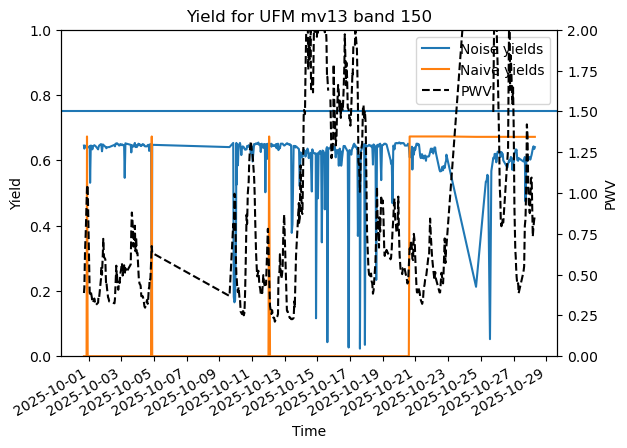

In [139]:
import matplotlib.dates as mdates

fig, ax = plt.subplots()
noise = ax.plot(times, noise_yields, label="Noise yields")
bias = ax.plot(times, naive_yields, label="Naive yields")

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Yield")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

ax.axhline(
    pton_df.loc[pton_df.labels == f"{band}_{ufm}", "yields"].to_numpy(), label="PTon"
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = noise + bias + pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"old_yield_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"old_yield_{ufm}_{band}.png", dpi=600)

plt.show()

In [140]:
cuts = cut_names[0]
for i in range(len(cut_names)):
    if i == 0:
        cut_dict = {}
        for name in cuts:
            cut_dict[name] = []
    for j, name in enumerate(cuts):
        cut_dict[name].append(n_cuts[i][j])


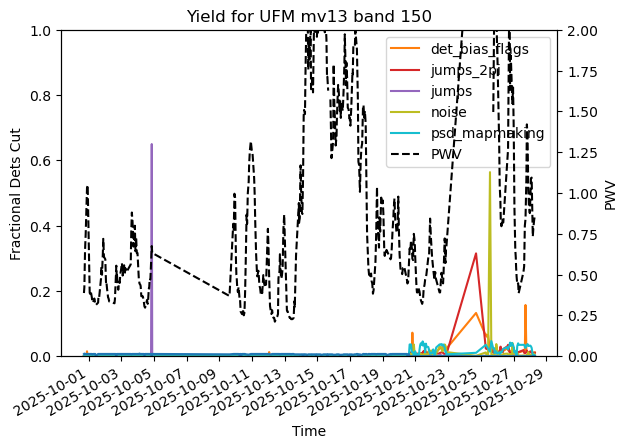

In [141]:
fig, ax = plt.subplots()
lns = []
for cut, n_cut in cut_dict.items():
    cur_ln = ax.plot(times, np.array(n_cut) / 860, label=cut)
    if np.amax(n_cut)>30 and cut !="source_flags":
        lns += cur_ln

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Fractional Dets Cut")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = lns+ pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"old_cuts_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"old_cuts_{ufm}_{band}.png", dpi=600)

plt.show()